<a href="https://colab.research.google.com/github/Balduino-BD/Agente-Tutor-de-Idiomas_Inteligencia_Artificial_UFSC/blob/main/T1_Regrecao.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# T1_APRENDIZADO SUPERVISIONADO

- CLASSIFICAÇÃO E REGRESSÃO



# DATASETS USADOS:

1. CLASSIFICASSÃO:

    FOI UTILIZADO O ARQUIVO "ONLINE_SHOPPERS_INTENTION.CSV" QUE CORRESPONDENTE AO DATASET ONLINE SHOPPERS PURCHASING INTENTION.
    - VARIAVEL: REVENUE.
    - OBJETIVO: CLASSIFICAR SE UMA SESSÃO DE NAVEGAÇÃO EM UMA LOJA VIRTUAL RESULTOU OU NÃO EM UMA COMPRA.

    - PROBLEMA: CLASSIFICAÇÃO BINÁRIA POIS A VARIAVEL REVENUE POSSUI DOIS POSSIVEIS RESULTADOS: TRUE, QUANDO HOUVE COMPRA E FALSE QUANDO NÃO HOUVE COMPRA.
2. REGRESSÃO:

    FOI UTILIZADO O ARQUIVO "DATA(1).CSV", CORRESPONDE AO DATASET HIGHER EDUCATION STUDENTS PERFOMANCE EVALUATION.

    - VARIAVEL: GRADE
    - OBJETIVO: PREVER NUMERICAMENTE A NOTA OU O DESEMPENHO FINAL DO ESTUDANTE COM BASE EM CARACTERISTICAS ACADÊMICAS, PESSOAIS E SOCIOECONÔMICAS.
    - PROBLEMA: REGRESSÃO PORQUE O VALOR GRADE, FOI TRATADO COMO VARIAVEL NUMERICA A SER ESTIMADA PELOS MODELOS.

  

3. MODELOS AVALIADOS

PARA O PROBLEMA DE CLASSIFICAÇÃO, FORAM AVALIADOS:
- REGRESSÃO LOGÍSTICA
- K-NEAREST NEIGHBORS/KNN;
- ARVORE DE DECISÃO;
- SUPPORT VECTOR MACHINE/SVM;
- MULTILAYER PERCEPTRON/MLP.

JÁ PARA MODELOS DE REGRESÃO, FORAM AVALIADOS:

- REGRESSÃO LINEAR;
- K-NEAREST NEIGHBORS REGRESSOR;
- ÁRVORE DE DECISÃO PARA REGRESSÃO;
- SUPPORT VECTOR REGRESSOR/SVR;
- MULTILAYER PERCEPTRON REGRESSOR

TAMBEM FORAM UTILIZADOS PIPELINE, COLUMTRANSFORMER, GRIDSEARCHCV E VALIDAÇÃO CRUZADA PARA ORGANIZAR O PRÉ-PROCESSAMENTO DOS DADOS, PROCURAR AS MELHORES COMBINAÇÕES DE HIPERPARÂMENTROS E AVALIAR A CAPACIDADE DE GENERALIZAÇÃO DOS MODELOS. NO FINAL OS  RESULTADOS FORAM COMPARADOS POR MEIO DE MÉTRICAS ESPECIFICAS PARA CLASSIFICAÇÃO E REGRESSÃO.

In [2]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


from sklearn.exceptions import ConvergenceWarning
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.neural_network import MLPClassifier, MLPRegressor

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

warnings.filterwarnings('ignore', category=ConvergenceWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', None)
RANDOM_STATE = 42

In [3]:
dados_c = pd.read_csv('/content/Dataset_T1/online_shoppers_intention.csv')

dados_r = pd.read_csv('/content/Dataset_T1/DATA (1).csv')

In [4]:
dados_c.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [5]:
dados_r.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   STUDENT ID  145 non-null    object
 1   1           145 non-null    int64 
 2   2           145 non-null    int64 
 3   3           145 non-null    int64 
 4   4           145 non-null    int64 
 5   5           145 non-null    int64 
 6   6           145 non-null    int64 
 7   7           145 non-null    int64 
 8   8           145 non-null    int64 
 9   9           145 non-null    int64 
 10  10          145 non-null    int64 
 11  11          145 non-null    int64 
 12  12          145 non-null    int64 
 13  13          145 non-null    int64 
 14  14          145 non-null    int64 
 15  15          145 non-null    int64 
 16  16          145 non-null    int64 
 17  17          145 non-null    int64 
 18  18          145 non-null    int64 
 19  19          145 non-null    int64 
 20  20        

In [6]:
dados_c.head(20)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [7]:
dados_c['Revenue'].value_counts()

,count
Revenue,
False,10422
True,1908


In [8]:
dados_c['Revenue'].value_counts(normalize=True) * 100

,proportion
Revenue,
False,84.525547
True,15.474453


In [9]:
dados_r.head(20)

,STUDENT ID,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,COURSE ID,GRADE
0,STUDENT1,2,2,3,3,1,2,2,1,1,1,1,2,3,1,2,5,3,2,2,1,1,1,1,1,3,2,1,2,1,1,1,1
1,STUDENT2,2,2,3,3,1,2,2,1,1,1,2,3,2,1,2,1,2,2,2,1,1,1,1,1,3,2,3,2,2,3,1,1
2,STUDENT3,2,2,2,3,2,2,2,2,4,2,2,2,2,1,2,1,2,1,2,1,1,1,1,1,2,2,1,1,2,2,1,1
3,STUDENT4,1,1,1,3,1,2,1,2,1,2,1,2,5,1,2,1,3,1,2,1,1,1,1,2,3,2,2,1,3,2,1,1
4,STUDENT5,2,2,1,3,2,2,1,3,1,4,3,3,2,1,2,4,2,1,1,1,1,1,2,1,2,2,2,1,2,2,1,1
5,STUDENT6,2,2,2,3,2,2,2,2,1,1,3,3,2,1,2,3,1,1,2,1,1,1,1,1,1,2,1,2,4,4,1,2
6,STUDENT7,1,2,2,4,2,2,2,1,1,3,1,3,1,1,2,4,2,2,2,2,1,2,1,1,3,3,3,3,4,4,1,5
7,STUDENT8,1,1,2,3,1,1,1,2,2,3,4,3,1,1,4,3,1,2,2,1,1,1,3,1,3,2,2,1,1,1,1,2
8,STUDENT9,2,1,3,3,2,1,1,1,1,3,2,4,2,1,2,4,1,2,2,1,1,1,1,1,3,2,2,2,4,3,1,5
9,STUDENT10,2,1,2,3,2,2,1,3,4,2,1,2,3,1,2,3,2,2,2,1,1,2,1,1,2,2,2,2,1,2,1,0


In [10]:
dados_r['GRADE'].value_counts()

,count
GRADE,
1,35
2,24
3,21
5,17
7,17
6,13
4,10
0,8


In [11]:
dados_r['GRADE'].value_counts(normalize=True).sort_index() * 100

,proportion
GRADE,
0,5.517241
1,24.137931
2,16.551724
3,14.482759
4,6.896552
5,11.724138
6,8.965517
7,11.724138


In [12]:
def verificar_valores_ausentes(df):
    print('Valores ausentes por coluna:')
    print(df.isnull().sum())
    print('\nTotal de valores ausentes:', df.isnull().sum().sum())

verificar_valores_ausentes(dados_r)

Valores ausentes por coluna:
STUDENT ID    0
1             0
2             0
3             0
4             0
5             0
6             0
7             0
8             0
9             0
10            0
11            0
12            0
13            0
14            0
15            0
16            0
17            0
18            0
19            0
20            0
21            0
22            0
23            0
24            0
25            0
26            0
27            0
28            0
29            0
30            0
COURSE ID     0
GRADE         0
dtype: int64

Total de valores ausentes: 0


In [13]:
print("Total de valores nulos em dados_c:", dados_c.isnull().sum().sum())
print("Total de valores nulos em dados_r:", dados_r.isnull().sum().sum())

Total de valores nulos em dados_c: 0
Total de valores nulos em dados_r: 0


In [14]:
print("Dimensões do dataset de classificação:")
print(dados_c.shape)

print("\nDimensões do dataset de regressão:")
print(dados_r.shape)

print("\nColunas do dataset de classificação:")
print(dados_c.columns.tolist())

print("\nColunas do dataset de regressão:")
print(dados_r.columns.tolist())

Dimensões do dataset de classificação:
(12330, 18)

Dimensões do dataset de regressão:
(145, 33)

Colunas do dataset de classificação:
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Colunas do dataset de regressão:
['STUDENT ID', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', 'COURSE ID', 'GRADE']


In [15]:
# Classificação
X_c = dados_c.drop(columns=['Revenue'])
y_c = dados_c['Revenue']

# Transformando o alvo booleano em 0 e 1, se necessário
if y_c.dtype == bool:
    y_c = y_c.astype(int)

# Regressão
X_r = dados_r.drop(columns=['STUDENT ID', 'GRADE'])
y_r = dados_r['GRADE']

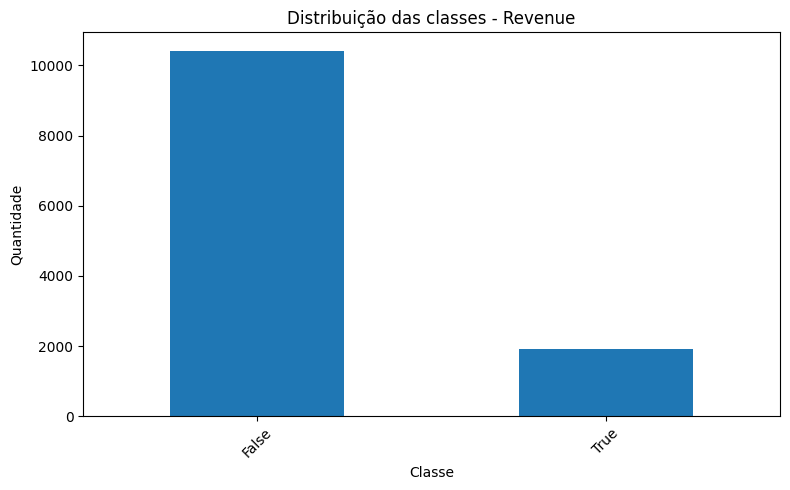

In [16]:
plt.figure(figsize=(8, 5))
dados_c['Revenue'].value_counts().plot(kind='bar')
plt.title('Distribuição das classes - Revenue')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

ANÁLISE EXPLORATÓRIA SIMPLES

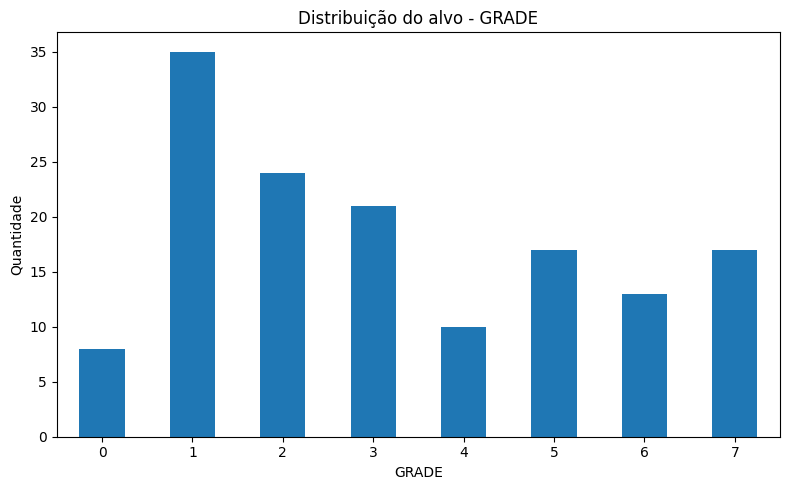

In [17]:
plt.figure(figsize=(8, 5))
dados_r['GRADE'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribuição do alvo - GRADE')
plt.xlabel('GRADE')
plt.ylabel('Quantidade')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

PREPARAÇÃO DOS DADOS

  TRATAMENTOS APLICADOS:

  - Conversão de valore em bytes do .arff para texto normal
  - Separação entre atributos de entrada x e variavel-alvo y.

In [18]:
# Classificação
X_c = dados_c.drop(columns=['Revenue'])
y_c = dados_c['Revenue']

# Regressão
colunas_remover_regressao = ['GRADE']
if 'STUDENT ID' in dados_r.columns:
    colunas_remover_regressao.append('STUDENT ID')

X_r = dados_r.drop(columns=colunas_remover_regressao)
y_r = dados_r['GRADE']

print('X_c:', X_c.shape, '| y_c:', y_c.shape)
print('X_r:', X_r.shape, '| y_r:', y_r.shape)

X_c: (12330, 17) | y_c: (12330,)
X_r: (145, 31) | y_r: (145,)


In [19]:
# Separação treino/teste
Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_c, y_c,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_c
)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_r, y_r,
    test_size=0.25,
    random_state=RANDOM_STATE
)

print('Treino classificação:', Xc_train.shape)
print('Teste classificação:', Xc_test.shape)
print('Treino regressão:', Xr_train.shape)
print('Teste regressão:', Xr_test.shape)

Treino classificação: (9247, 17)
Teste classificação: (3083, 17)
Treino regressão: (108, 31)
Teste regressão: (37, 31)


FUNÇÕES AUXILIARES PARA PRÉ-PROCESSAMENTO E AVALIAÇÃO

As funções abaixo criam os pipelines de processamento e calculam as métricas de avaliação.

In [20]:
def criar_onehot_encoder():
    """Cria OneHotEncoder compatível com versões diferentes do scikit-learn."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)


def criar_preprocessador(X):
    """Cria um ColumnTransformer separando colunas numéricas e categóricas."""
    colunas_numericas = X.select_dtypes(include=['int64', 'float64', 'int32', 'float32', 'bool']).columns.tolist()
    colunas_categoricas = [col for col in X.columns if col not in colunas_numericas]

    transformadores = []

    if len(colunas_numericas) > 0:
        transformadores.append(('num', StandardScaler(), colunas_numericas))

    if len(colunas_categoricas) > 0:
        transformadores.append(('cat', criar_onehot_encoder(), colunas_categoricas))

    return ColumnTransformer(transformers=transformadores, remainder='drop')


def calcular_rmse(y_true, y_pred):
    """Calcula RMSE mantendo compatibilidade com versões diferentes do scikit-learn."""
    try:
        return mean_squared_error(y_true, y_pred, squared=False)
    except TypeError:
        return np.sqrt(mean_squared_error(y_true, y_pred))

PARTE 1- CLASSIFICAÇÃO

TREINAMENTO COM PIPELINE, GRIDSEARCHCV E CROSS VALIDATION

In [21]:
preprocessador_classificacao = criar_preprocessador(X_c)
cv_classificacao = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

modelos_classificacao = {
    'Regressão Logística': {
        'modelo': LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
        'parametros': {
            'modelo__C': [1]
        }
    },
    'KNN': {
        'modelo': KNeighborsClassifier(),
        'parametros': {
            'modelo__n_neighbors': [5],
            'modelo__weights': ['uniform', 'distance']
        }
    },
    'Árvore de Decisão': {
        'modelo': DecisionTreeClassifier(random_state=RANDOM_STATE),
        'parametros': {
            'modelo__max_depth': [None, 5],
            'modelo__min_samples_split': [2]
        }
    },
    'SVM': {
        'modelo': SVC(random_state=RANDOM_STATE),
        'parametros': {
            'modelo__C': [1],
            'modelo__kernel': ['linear', 'rbf']
        }
    },
    'MLP': {
        'modelo': MLPClassifier(hidden_layer_sizes=(20,), max_iter=200, solver='lbfgs', random_state=RANDOM_STATE),
        'parametros': {
            'modelo__hidden_layer_sizes': [(20,)],
            'modelo__alpha': [0.0001]
        }
    }
}

resultados_classificacao = []
melhores_modelos_classificacao = {}

for nome, config in modelos_classificacao.items():
    print(f'Treinando: {nome}')

    pipeline = Pipeline(steps=[
        ('preprocessamento', preprocessador_classificacao),
        ('modelo', config['modelo'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['parametros'],
        scoring='f1_macro',
        cv=cv_classificacao,
        n_jobs=1
    )

    grid.fit(Xc_train, yc_train)
    melhores_modelos_classificacao[nome] = grid.best_estimator_

    pred = grid.predict(Xc_test)

    resultados_classificacao.append({
        'Modelo': nome,
        'Melhor F1-macro CV': grid.best_score_,
        'Acurácia teste': accuracy_score(yc_test, pred),
        'Precisão macro teste': precision_score(yc_test, pred, average='macro', zero_division=0),
        'Recall macro teste': recall_score(yc_test, pred, average='macro', zero_division=0),
        'F1-macro teste': f1_score(yc_test, pred, average='macro', zero_division=0),
        'Melhores parâmetros': grid.best_params_
    })

resultados_classificacao_df = pd.DataFrame(resultados_classificacao)
resultados_classificacao_df = resultados_classificacao_df.sort_values(by='F1-macro teste', ascending=False)
display(resultados_classificacao_df)

Treinando: Regressão Logística
Treinando: KNN
Treinando: Árvore de Decisão
Treinando: SVM
Treinando: MLP


,Modelo,Melhor F1-macro CV,Acurácia teste,Precisão macro teste,Recall macro teste,F1-macro teste,Melhores parâmetros
2,Árvore de Decisão,0.795633,0.896205,0.819133,0.751062,0.778594,"{'modelo__max_depth': 5, 'modelo__min_samples_..."
4,MLP,0.779840,0.891340,0.800648,0.758460,0.776914,"{'modelo__alpha': 0.0001, 'modelo__hidden_laye..."
3,SVM,0.766152,0.885501,0.802625,0.710476,0.743474,"{'modelo__C': 1, 'modelo__kernel': 'rbf'}"
0,Regressão Logística,0.727885,0.878041,0.803198,0.663246,0.701485,{'modelo__C': 1}
1,KNN,0.715049,0.866688,0.753885,0.663381,0.692634,"{'modelo__n_neighbors': 5, 'modelo__weights': ..."


GRÁFICOS COMPARATIVOS

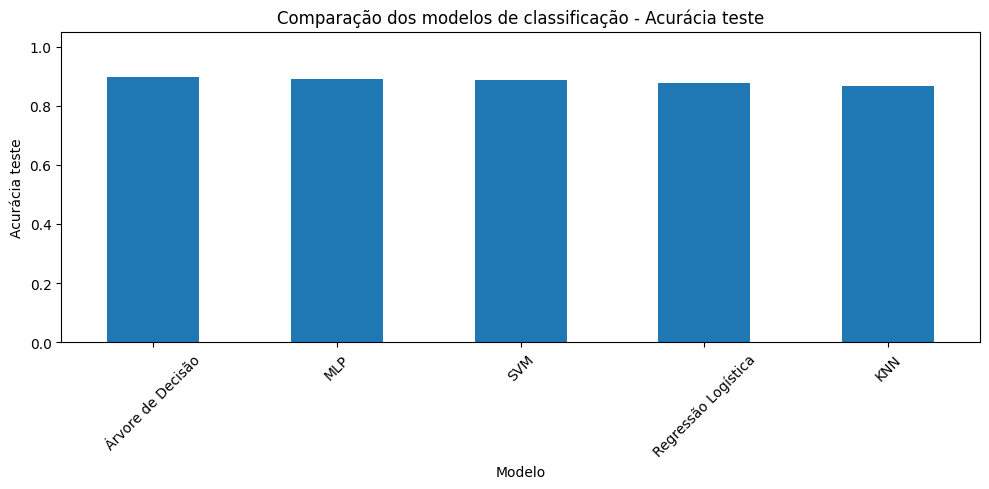

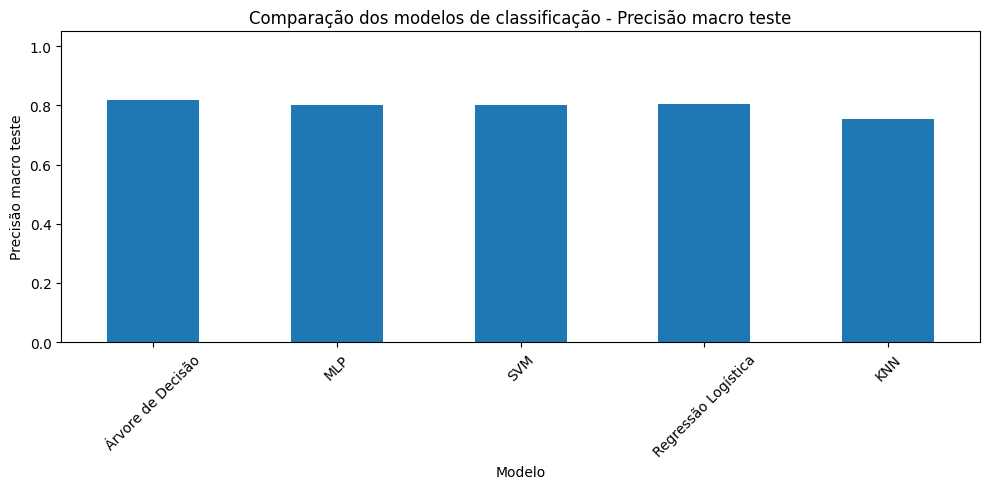

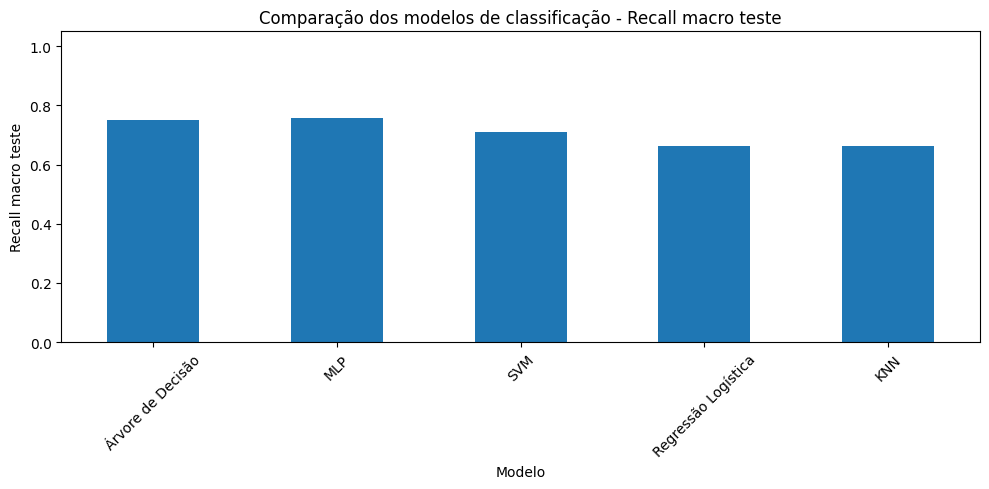

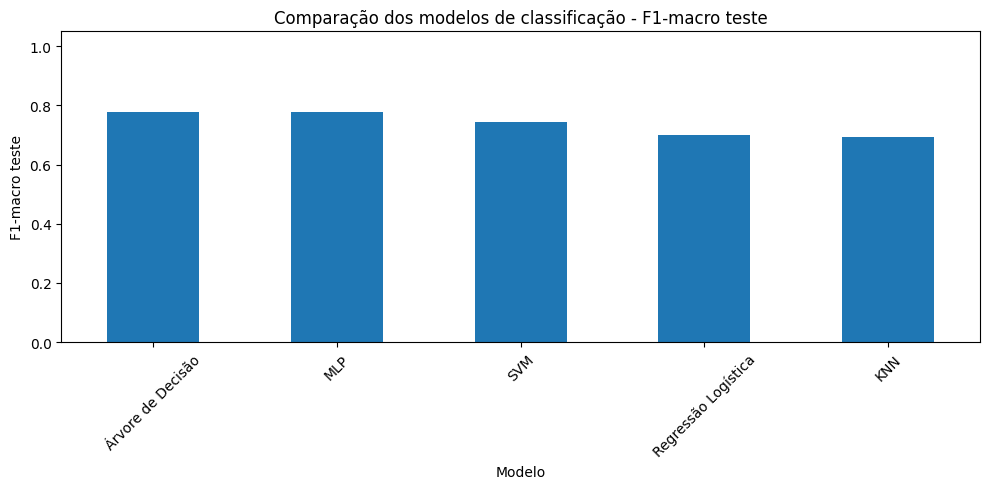

In [22]:
metricas_classificacao = [
    'Acurácia teste',
    'Precisão macro teste',
    'Recall macro teste',
    'F1-macro teste'
]

for metrica in metricas_classificacao:
    plt.figure(figsize=(10, 5))
    resultados_classificacao_df.set_index('Modelo')[metrica].plot(kind='bar')
    plt.title(f'Comparação dos modelos de classificação - {metrica}')
    plt.ylabel(metrica)
    plt.xlabel('Modelo')
    plt.xticks(rotation=45)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()

RELATÓRIO MELHOR MODELO DE CLASSIFICAÇÃO

Melhor modelo de classificação: Árvore de Decisão

Relatório de classificação:
              precision    recall  f1-score   support

       False       0.92      0.96      0.94      2606
        True       0.72      0.54      0.62       477

    accuracy                           0.90      3083
   macro avg       0.82      0.75      0.78      3083
weighted avg       0.89      0.90      0.89      3083



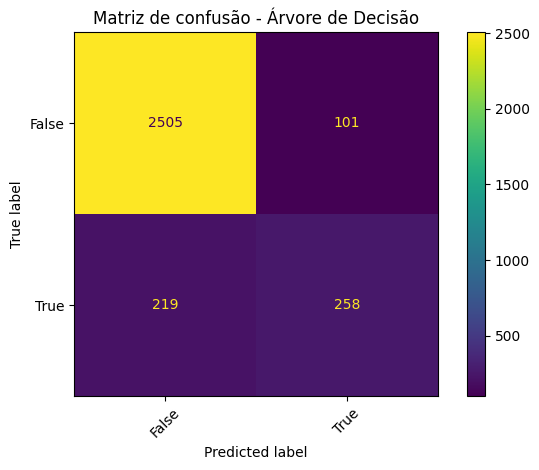

In [23]:
melhor_nome_classificacao = resultados_classificacao_df.iloc[0]['Modelo']
melhor_modelo_classificacao = melhores_modelos_classificacao[melhor_nome_classificacao]

pred_melhor_classificacao = melhor_modelo_classificacao.predict(Xc_test)

print('Melhor modelo de classificação:', melhor_nome_classificacao)
print('\nRelatório de classificação:')
print(classification_report(yc_test, pred_melhor_classificacao, zero_division=0))

matriz = confusion_matrix(yc_test, pred_melhor_classificacao)
disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=melhor_modelo_classificacao.classes_)
disp.plot(values_format='d')
plt.title(f'Matriz de confusão - {melhor_nome_classificacao}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

CROSS VALIDATIO DO MELHOR MODELO DE CLASSIFICAÇÃO

In [24]:
scoring_classificacao = {
    'accuracy': 'accuracy',
    'precision_macro': 'precision_macro',
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro'
}

cv_result_class = cross_validate(
    melhor_modelo_classificacao,
    X_c,
    y_c,
    cv=cv_classificacao,
    scoring=scoring_classificacao,
    n_jobs=1
)

resumo_cv_class = pd.DataFrame({
    'Métrica': ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro'],
    'Média CV': [
        cv_result_class['test_accuracy'].mean(),
        cv_result_class['test_precision_macro'].mean(),
        cv_result_class['test_recall_macro'].mean(),
        cv_result_class['test_f1_macro'].mean()
    ],
    'Desvio padrão CV': [
        cv_result_class['test_accuracy'].std(),
        cv_result_class['test_precision_macro'].std(),
        cv_result_class['test_recall_macro'].std(),
        cv_result_class['test_f1_macro'].std()
    ]
})

display(resumo_cv_class)

,Métrica,Média CV,Desvio padrão CV
0,accuracy,0.897405,0.003533
1,precision_macro,0.821047,0.013704
2,recall_macro,0.757558,0.006867
3,f1_macro,0.783283,0.003210


PARTE 2- REGRESSÃO

TREINAMENTO COM PIPELINE, GRIDSEARCHCV E CROS VALIDATION

In [25]:
preprocessador_regressao = criar_preprocessador(X_r)
cv_regressao = KFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

modelos_regressao = {
    'Regressão Linear': {
        'modelo': LinearRegression(),
        'parametros': {}
    },
    'KNN Regressor': {
        'modelo': KNeighborsRegressor(),
        'parametros': {
            'modelo__n_neighbors': [5],
            'modelo__weights': ['uniform', 'distance']
        }
    },
    'Árvore de Decisão Regressora': {
        'modelo': DecisionTreeRegressor(random_state=RANDOM_STATE),
        'parametros': {
            'modelo__max_depth': [None, 5],
            'modelo__min_samples_leaf': [1, 3]
        }
    },
    'SVM Regressor': {
        'modelo': SVR(),
        'parametros': {
            'modelo__C': [1],
            'modelo__kernel': ['linear', 'rbf'],
            'modelo__epsilon': [0.1]
        }
    },
    'MLP Regressor': {
        'modelo': MLPRegressor(hidden_layer_sizes=(20,), max_iter=300, solver='lbfgs', random_state=RANDOM_STATE),
        'parametros': {
            'modelo__hidden_layer_sizes': [(20,)],
            'modelo__alpha': [0.0001]
        }
    }
}

resultados_regressao = []
melhores_modelos_regressao = {}

for nome, config in modelos_regressao.items():
    print(f'Treinando: {nome}')

    pipeline = Pipeline(steps=[
        ('preprocessamento', preprocessador_regressao),
        ('modelo', config['modelo'])
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=config['parametros'],
        scoring='neg_mean_squared_error',
        cv=cv_regressao,
        n_jobs=1
    )

    grid.fit(Xr_train, yr_train)
    melhores_modelos_regressao[nome] = grid.best_estimator_

    pred = grid.predict(Xr_test)

    resultados_regressao.append({
        'Modelo': nome,
        'Melhor MSE CV': -grid.best_score_,
        'MAE teste': mean_absolute_error(yr_test, pred),
        'RMSE teste': calcular_rmse(yr_test, pred),
        'R² teste': r2_score(yr_test, pred),
        'Melhores parâmetros': grid.best_params_
    })

resultados_regressao_df = pd.DataFrame(resultados_regressao)
resultados_regressao_df = resultados_regressao_df.sort_values(by='RMSE teste', ascending=True)
display(resultados_regressao_df)

Treinando: Regressão Linear
Treinando: KNN Regressor
Treinando: Árvore de Decisão Regressora
Treinando: SVM Regressor
Treinando: MLP Regressor


,Modelo,Melhor MSE CV,MAE teste,RMSE teste,R² teste,Melhores parâmetros
2,Árvore de Decisão Regressora,3.719972,1.184572,1.518707,0.480494,"{'modelo__max_depth': 5, 'modelo__min_samples_..."
1,KNN Regressor,4.275637,1.656072,2.016003,0.084570,"{'modelo__n_neighbors': 5, 'modelo__weights': ..."
3,SVM Regressor,4.139590,1.642258,2.025206,0.076194,"{'modelo__C': 1, 'modelo__epsilon': 0.1, 'mode..."
0,Regressão Linear,4.900343,2.068514,2.649588,-0.581246,{}
4,MLP Regressor,5.077373,2.261988,2.966614,-0.982280,"{'modelo__alpha': 0.0001, 'modelo__hidden_laye..."


GRAFICOS COMPARATIVOS-REGRESSÃO

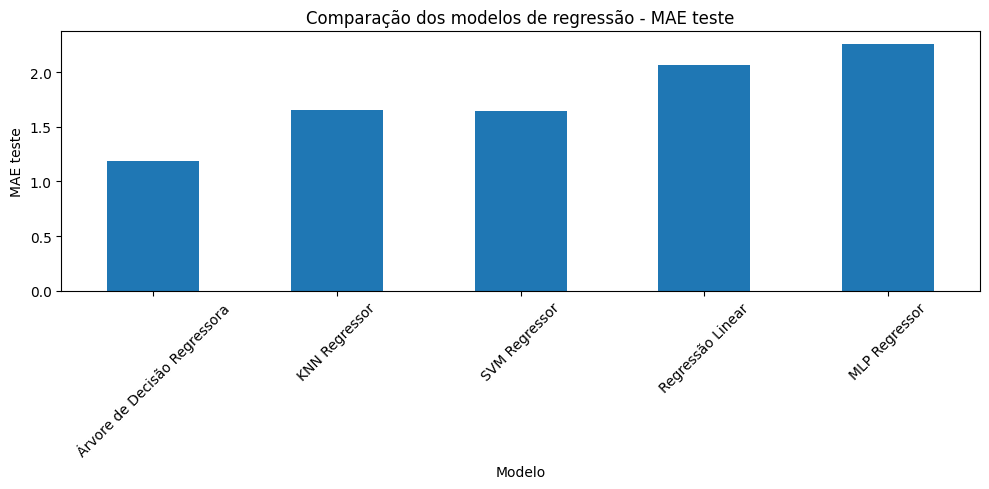

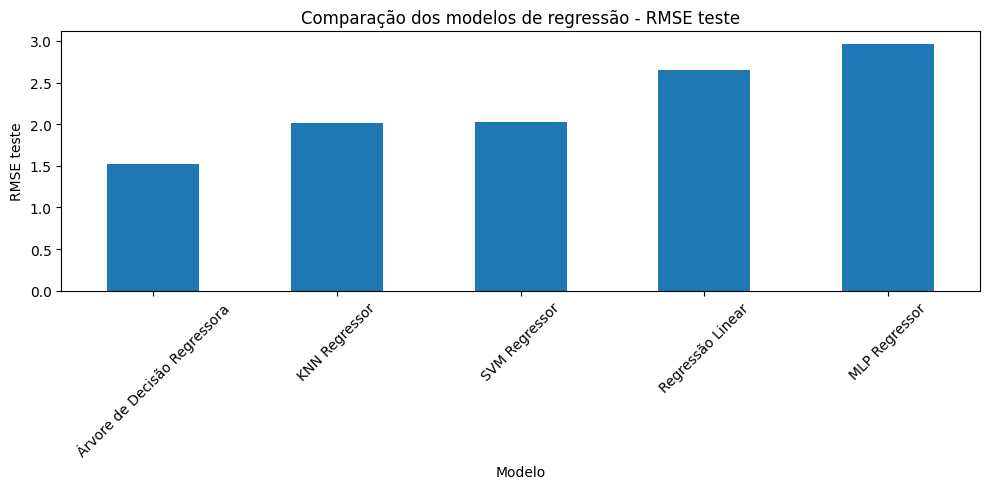

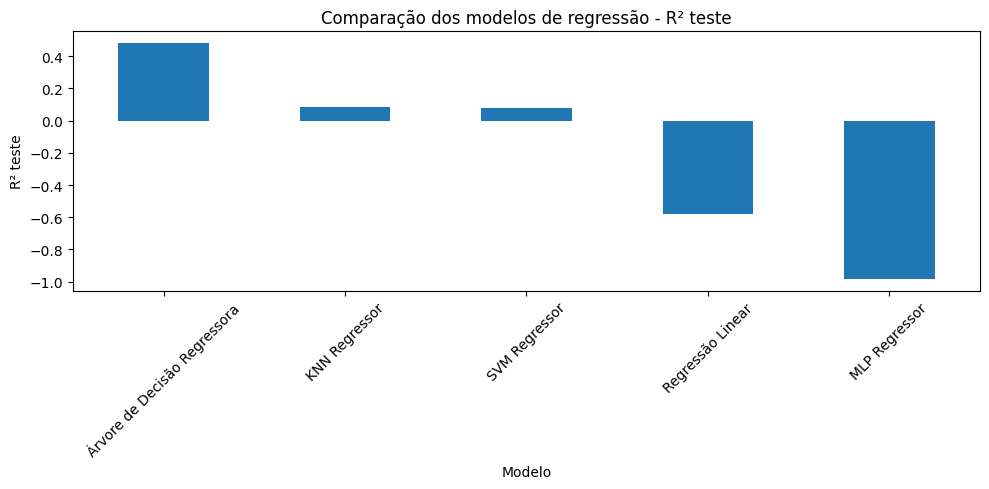

In [26]:
metricas_regressao = ['MAE teste', 'RMSE teste', 'R² teste']

for metrica in metricas_regressao:
    plt.figure(figsize=(10, 5))
    resultados_regressao_df.set_index('Modelo')[metrica].plot(kind='bar')
    plt.title(f'Comparação dos modelos de regressão - {metrica}')
    plt.ylabel(metrica)
    plt.xlabel('Modelo')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

ANÁLISE DO MELHOR MODELO DE REGRESSÃO

Melhor modelo de regressão: Árvore de Decisão Regressora
MAE: 1.184572072072072
RMSE: 1.5187067076344312
R²: 0.48049399187872477


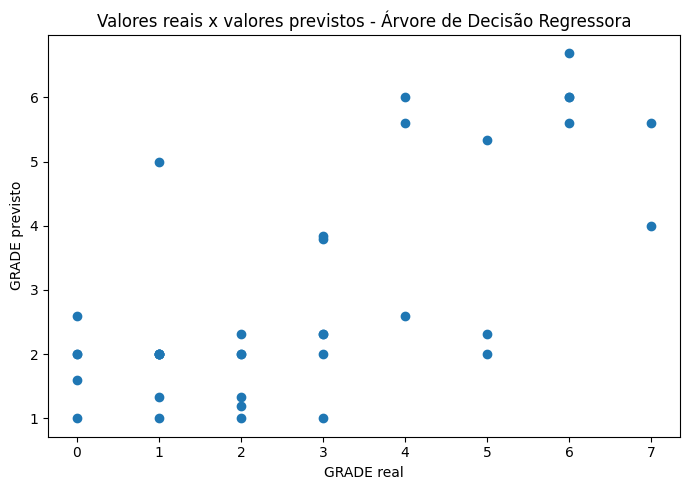

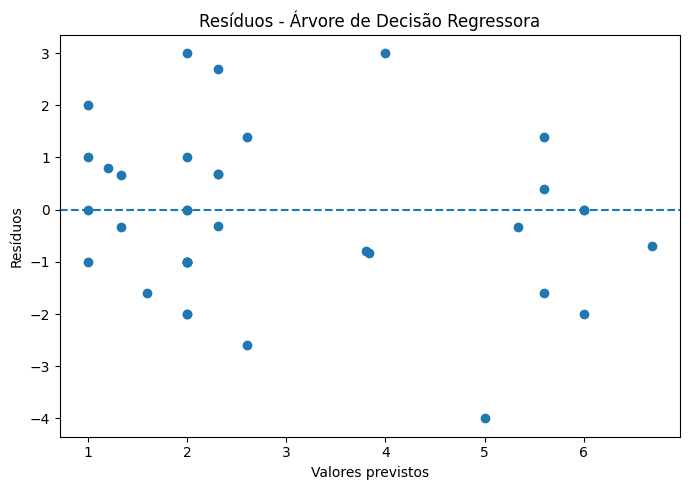

In [27]:
melhor_nome_regressao = resultados_regressao_df.iloc[0]['Modelo']
melhor_modelo_regressao = melhores_modelos_regressao[melhor_nome_regressao]

pred_melhor_regressao = melhor_modelo_regressao.predict(Xr_test)
residuos = yr_test - pred_melhor_regressao

print('Melhor modelo de regressão:', melhor_nome_regressao)
print('MAE:', mean_absolute_error(yr_test, pred_melhor_regressao))
print('RMSE:', calcular_rmse(yr_test, pred_melhor_regressao))
print('R²:', r2_score(yr_test, pred_melhor_regressao))

plt.figure(figsize=(7, 5))
plt.scatter(yr_test, pred_melhor_regressao)
plt.title(f'Valores reais x valores previstos - {melhor_nome_regressao}')
plt.xlabel('GRADE real')
plt.ylabel('GRADE previsto')
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(pred_melhor_regressao, residuos)
plt.axhline(0, linestyle='--')
plt.title(f'Resíduos - {melhor_nome_regressao}')
plt.xlabel('Valores previstos')
plt.ylabel('Resíduos')
plt.tight_layout()
plt.show()

CROSS VALIDATION DO MELHOR MODELO DE REGRESSÃO

In [28]:
scoring_regressao = {
    'mae': 'neg_mean_absolute_error',
    'mse': 'neg_mean_squared_error',
    'r2': 'r2'
}

cv_result_reg = cross_validate(
    melhor_modelo_regressao,
    X_r,
    y_r,
    cv=cv_regressao,
    scoring=scoring_regressao,
    n_jobs=1
)

resumo_cv_reg = pd.DataFrame({
    'Métrica': ['MAE', 'RMSE', 'R²'],
    'Média CV': [
        -cv_result_reg['test_mae'].mean(),
        np.sqrt(-cv_result_reg['test_mse'].mean()),
        cv_result_reg['test_r2'].mean()
    ],
    'Desvio padrão CV': [
        cv_result_reg['test_mae'].std(),
        np.sqrt(cv_result_reg['test_mse'].var()),
        cv_result_reg['test_r2'].std()
    ]
})

display(resumo_cv_reg)

,Métrica,Média CV,Desvio padrão CV
0,MAE,1.292972,0.078174
1,RMSE,1.611171,0.243949
2,R²,0.418611,0.149921


In [29]:
print('Resumo final - Classificação')
print('Melhor modelo:', melhor_nome_classificacao)
print('F1-macro teste:', resultados_classificacao_df.iloc[0]['F1-macro teste'])
print('Acurácia teste:', resultados_classificacao_df.iloc[0]['Acurácia teste'])

print('\nResumo final - Regressão')
print('Melhor modelo:', melhor_nome_regressao)
print('RMSE teste:', resultados_regressao_df.iloc[0]['RMSE teste'])
print('MAE teste:', resultados_regressao_df.iloc[0]['MAE teste'])
print('R² teste:', resultados_regressao_df.iloc[0]['R² teste'])

Resumo final - Classificação
Melhor modelo: Árvore de Decisão
F1-macro teste: 0.7785936784653087
Acurácia teste: 0.8962049951346092

Resumo final - Regressão
Melhor modelo: Árvore de Decisão Regressora
RMSE teste: 1.5187067076344312
MAE teste: 1.184572072072072
R² teste: 0.48049399187872477


REFERENCIAS BIBLIOGRAFICAS

- UCI Machine Learning Repository — Student Performance on an Entrance Examination.
- UCI Machine Learning Repository — Higher Education Students Performance Evaluation.
- CHAT GPT(OPEN AI)
- GEMINI